## Import and eval functions

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, h5py, gc, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import concurrent.futures as cf
from pathlib import Path
from torch.utils.data import DataLoader

REPO_ROOT = "./"
proj = Path(REPO_ROOT).resolve()

# allow: import ADCNN.*
sys.path.insert(0, str(proj))

# allow: import utils.*  (where utils == ADCNN/utils)
sys.path.insert(0, str(proj / "ADCNN"))

import ADCNN.inference.postprocess as postprocess
from ADCNN.data.datasets import H5TiledDataset
from ADCNN.inference.predict import load_model, predict_tiles_to_full
import ADCNN.evaluation.detection as evals
import ADCNN.evaluation.threshold_scan as threshold_scan

test_h5 = "./DATA/test.h5"
test_csv = "./DATA/test.csv"
MODEL_CKPT = "./checkpoints/ckpt_best.pt"

In [2]:
def calculate_model_metrics (catalog, predictions, ground_truth, thr_points=100, stack_fp=None, best_threshold=None):
    catalog = catalog.copy()
    threshold_df = threshold_scan.scan_thresholds(catalog=catalog, predictions=predictions, ground_truth=ground_truth, stack_fp=stack_fp, n_points=thr_points)
    threshold_scan.plot_fscore(threshold_df["thr"], pix_f1=threshold_df.get("pix_f1"), pix_f2=threshold_df.get("pix_f2"),
                               obj_f1=threshold_df.get("obj_f1"), obj_f2=threshold_df.get("obj_f2"), title="Pixelwise vs Objectwise F-scores")
    threshold_scan.plot_roc(threshold_scan.compute_roc(threshold_df["pix_tp"], threshold_df["pix_fp"], threshold_df["pix_tn"], threshold_df["pix_fn"]))
    threshold_scan.plot_froc(threshold_scan.compute_froc(thr=threshold_df["thr"], obj_tp=threshold_df["obj_tp"], obj_fp=threshold_df["obj_fp"], obj_fn=threshold_df["obj_fn"], n_images=50),
                             title="FROC (objectwise)")
    if best_threshold is None:
        best_threshold = threshold_df["thr"][threshold_df["obj_f2"].argmax()]
    _,_,catalog = evals.full_confusion(catalog=catalog, ground_truth= ground_truth,predictions=predictions, stack_fp=stack_fp, threshold=best_threshold, verbose=True)
    _ = evals.plot_detect_hist(catalog, "PSF_mag", bins=12, title="NN detections vs PSF_mag threshold=" + str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "trail_length", bins=12, title="Detections vs trail length threshold="+ str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "SNR", bins=10, title="Detections vs SNR threshold="+ str(round(best_threshold, 3)), xlim=[0, 10], density=True)
    plt.show()
    return catalog

In [3]:
ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

In [4]:
def get_stack_metrics (catalog, fp_mask):
    tp = (catalog["stack_detection"]==True).sum()
    fn = (catalog["stack_detection"]==False).sum()
    fp = fp_mask.max(axis=(1, 2)).sum()
    return  {"TP": tp, "FP": fp, "FN": fn, "TN": pd.NA}

evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")

Object-wise Confusion Matrix
F1 Score: 0.0190, F2 Score: 0.0455
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               63932
Actual Positive                 376                 624



## Model

In [5]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_best.pt
Predictions shape: (50, 4004, 4096)


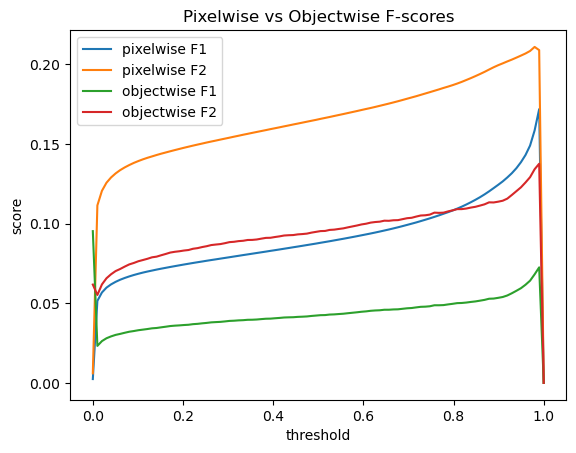

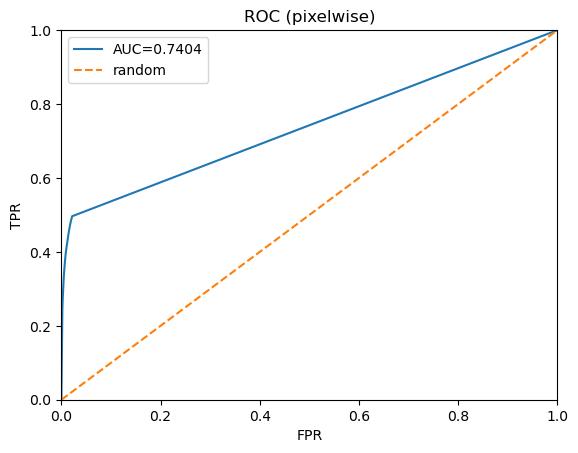

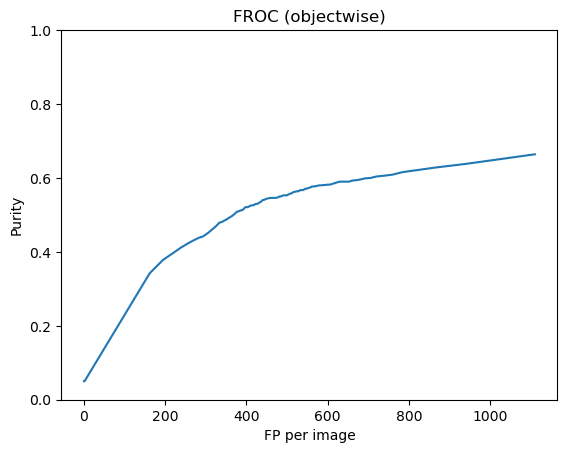

Object-level Confusion Matrix
F1 Score: 0.0728, F2 Score: 0.1380
                 Predicted Negative  Predicted Positive
Actual Negative                   0                8049
Actual Positive                 658                 342

Pixel-level Confusion Matrix
F1 Score: 0.1721, F2 Score: 0.2087
                 Predicted Negative  Predicted Positive
Actual Negative           817452626             1573322
Actual Positive              751640              241612



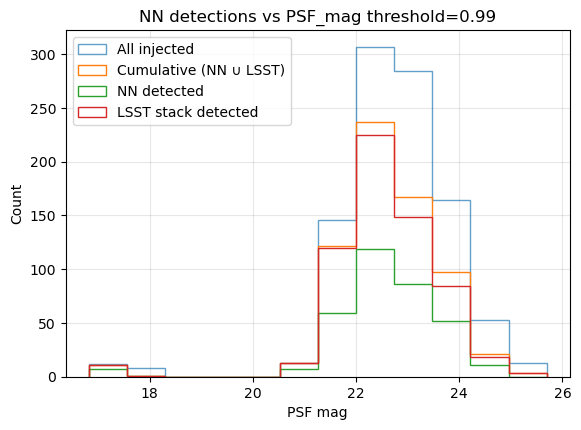

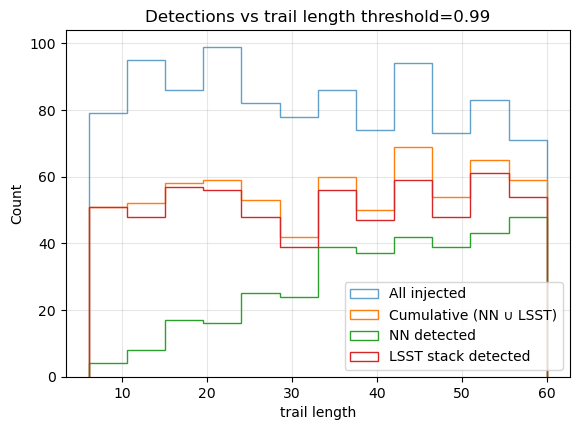

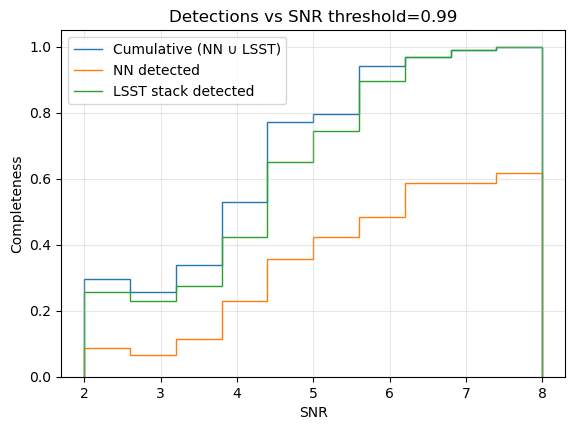

In [6]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

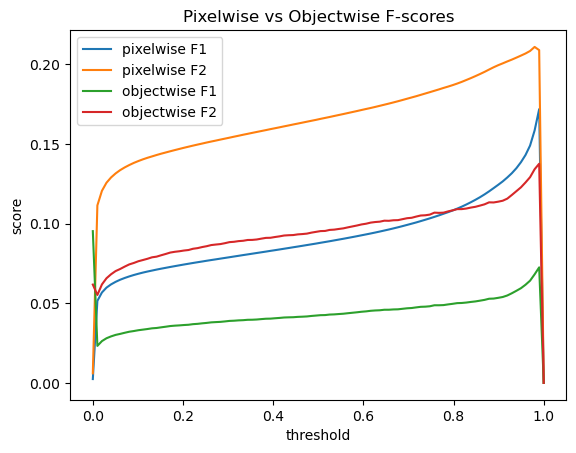

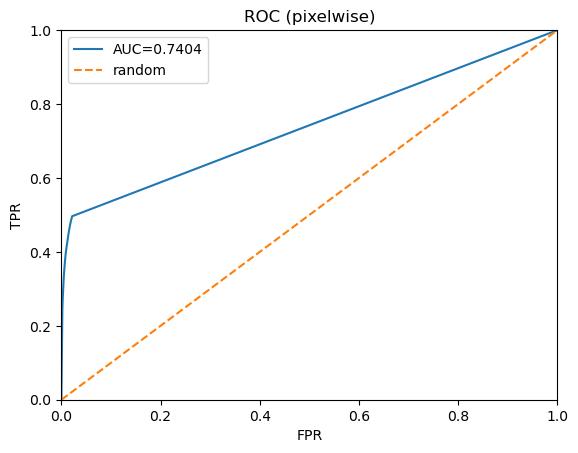

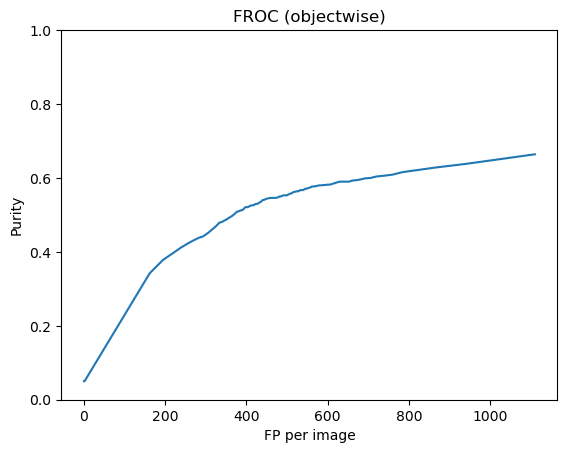

Object-level Confusion Matrix
F1 Score: 0.0425, F2 Score: 0.0952
                 Predicted Negative  Predicted Positive
Actual Negative                   0               24479
Actual Positive                 447                 553

Pixel-level Confusion Matrix
F1 Score: 0.0877, F2 Score: 0.1654
                 Predicted Negative  Predicted Positive
Actual Negative           811269549             7756399
Actual Positive              592000              401252



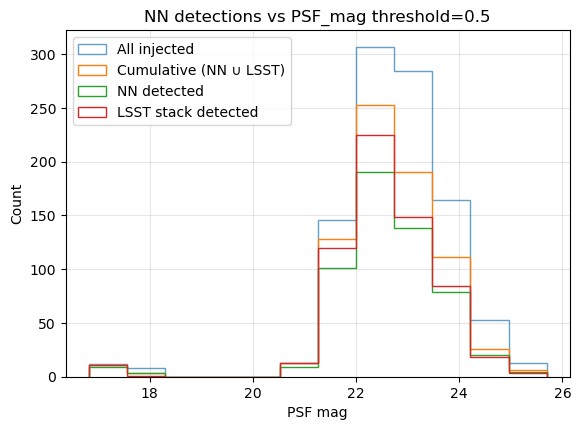

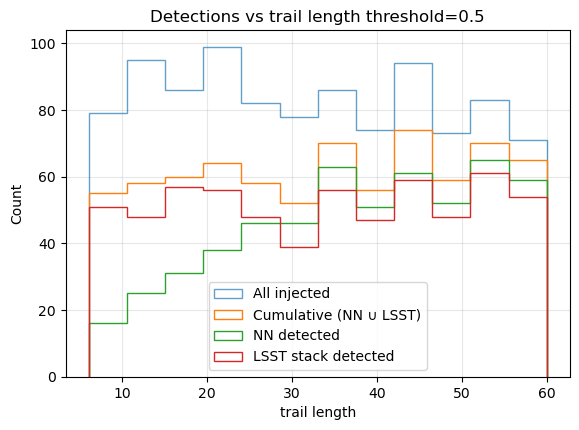

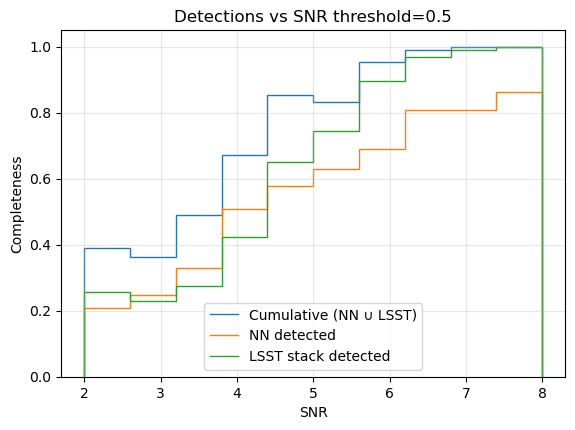

In [7]:
*__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

In [8]:
p_tt = postprocess.two_threshold_prediction(p, t_low=0.07, pixel_gap=1)

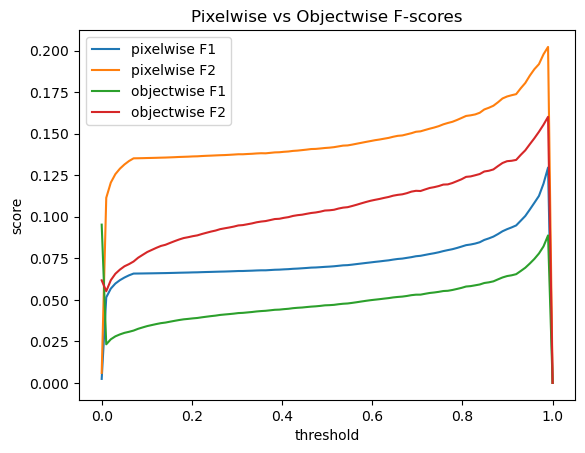

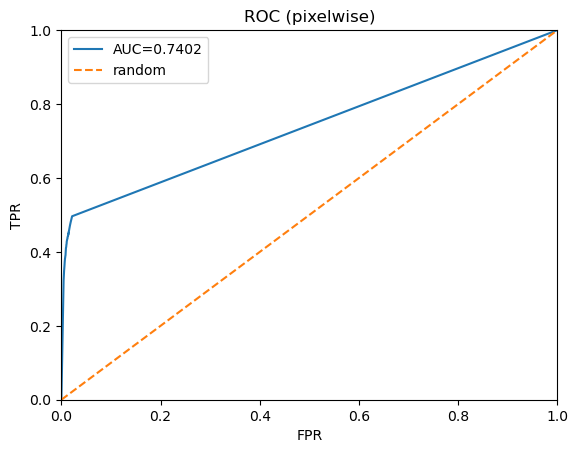

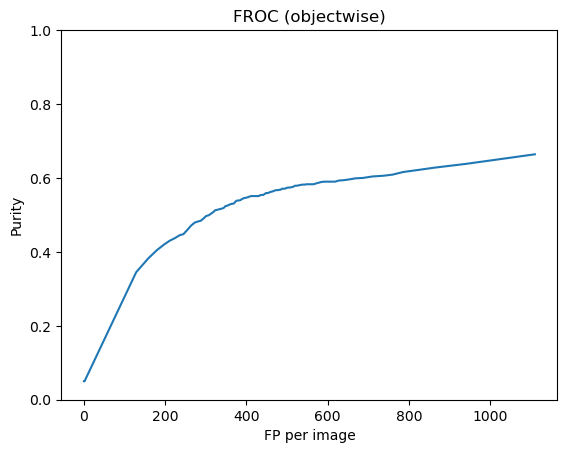

Object-level Confusion Matrix
F1 Score: 0.0888, F2 Score: 0.1601
                 Predicted Negative  Predicted Positive
Actual Negative                   0                6429
Actual Positive                 655                 345

Pixel-level Confusion Matrix
F1 Score: 0.1299, F2 Score: 0.2025
                 Predicted Negative  Predicted Positive
Actual Negative           815405733             3620215
Actual Positive              672724              320528



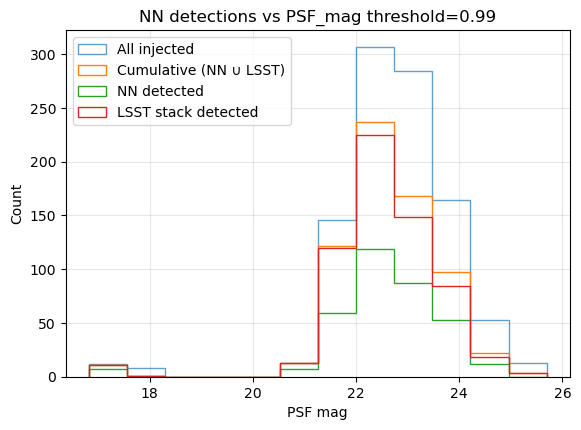

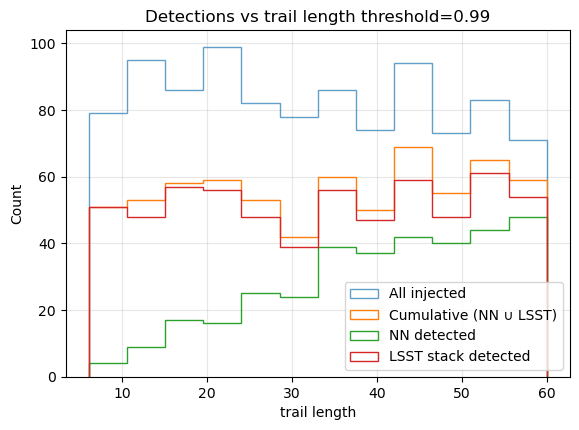

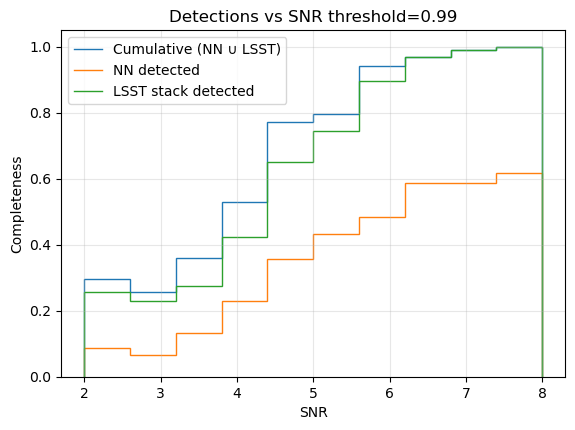

In [9]:
__ = calculate_model_metrics(test_catalog, p_tt, gt_test, stack_fp=stack_fp)

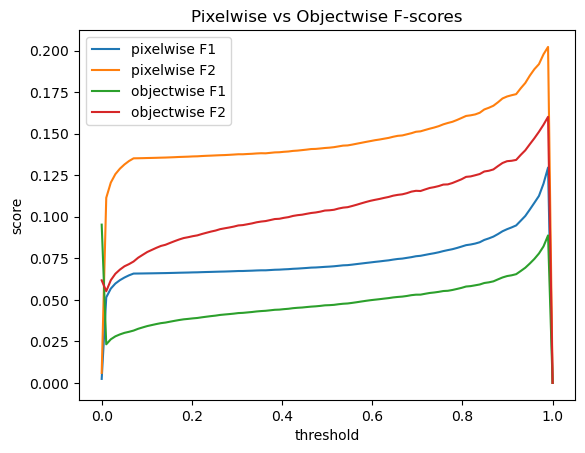

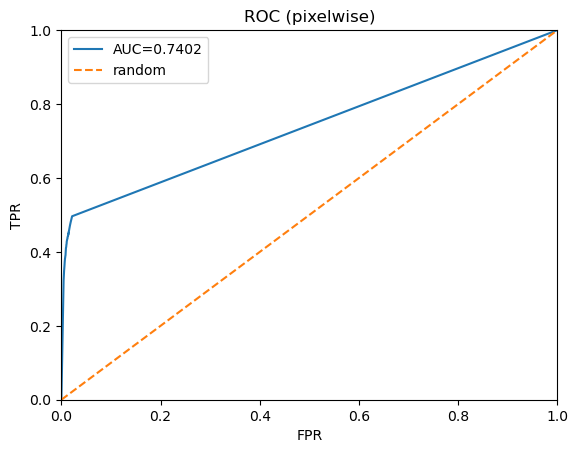

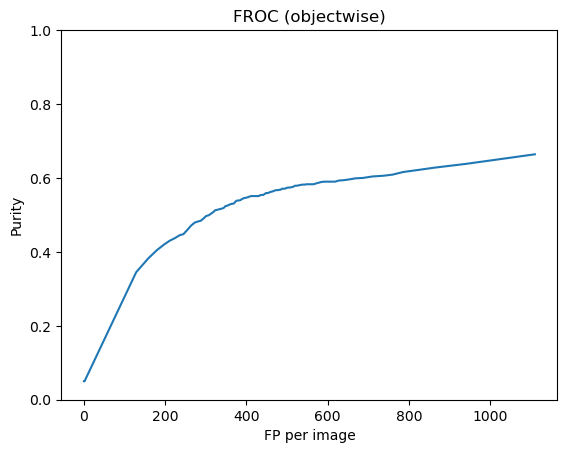

Object-level Confusion Matrix
F1 Score: 0.0467, F2 Score: 0.1037
                 Predicted Negative  Predicted Positive
Actual Negative                   0               22287
Actual Positive                 443                 557

Pixel-level Confusion Matrix
F1 Score: 0.0699, F2 Score: 0.1415
                 Predicted Negative  Predicted Positive
Actual Negative           807811387            11214561
Actual Positive              550812              442440



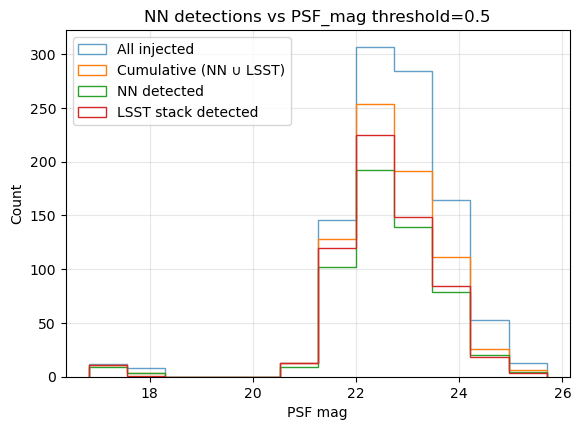

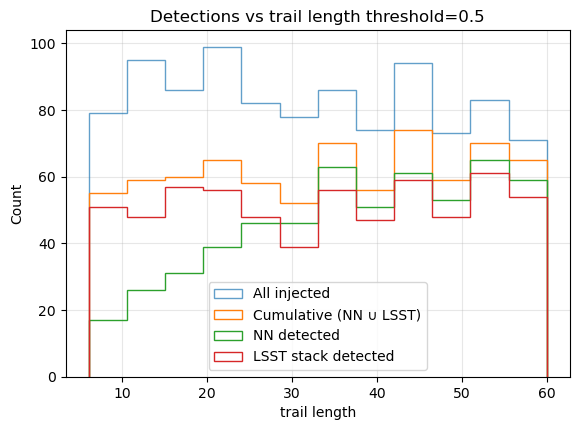

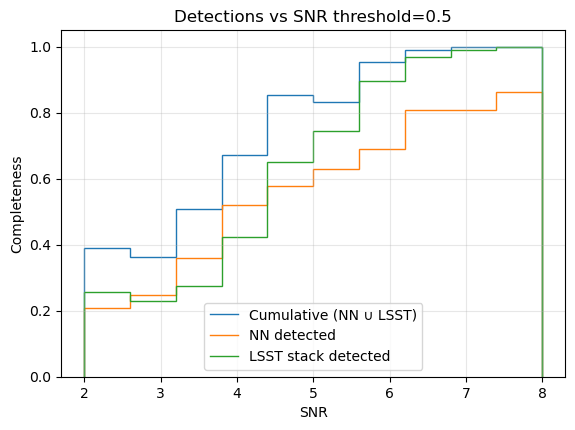

In [10]:
__ = calculate_model_metrics(test_catalog, p_tt, gt_test, stack_fp=stack_fp, best_threshold=0.5)

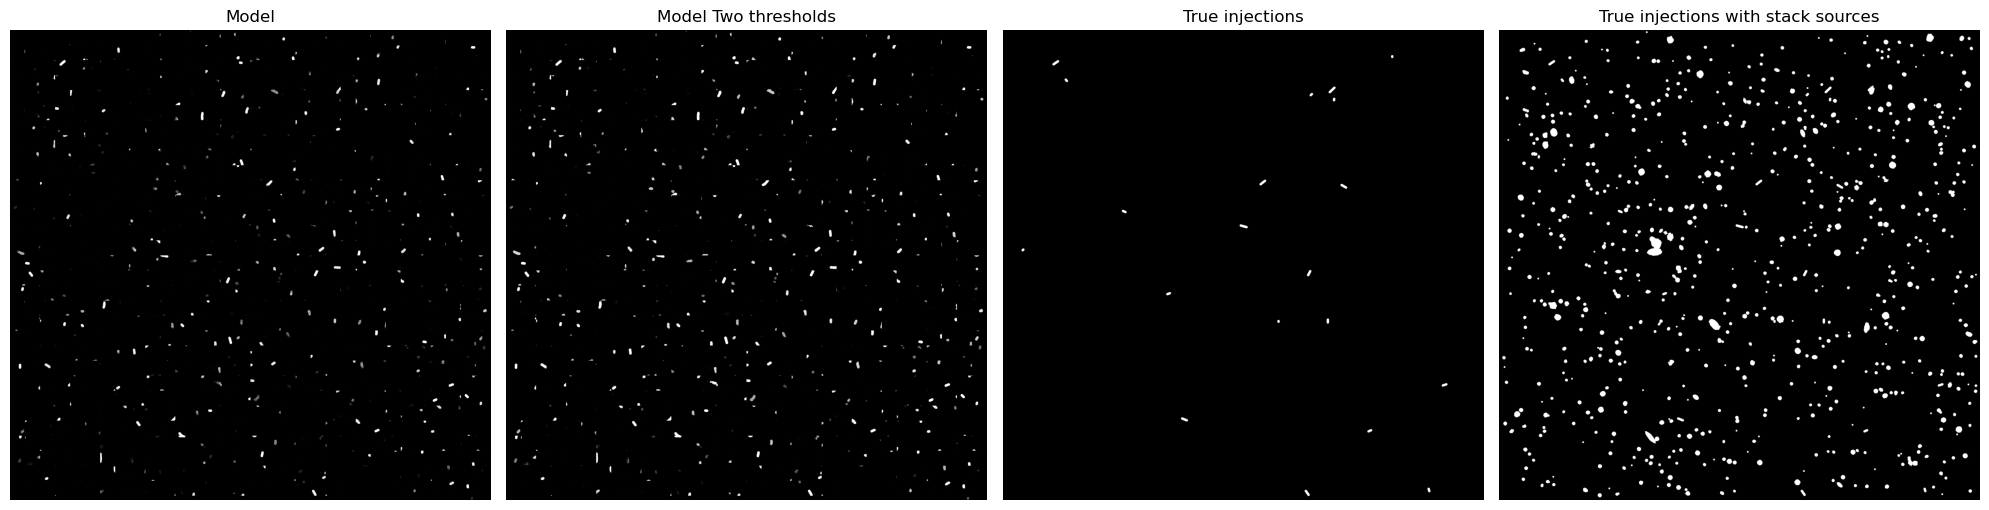

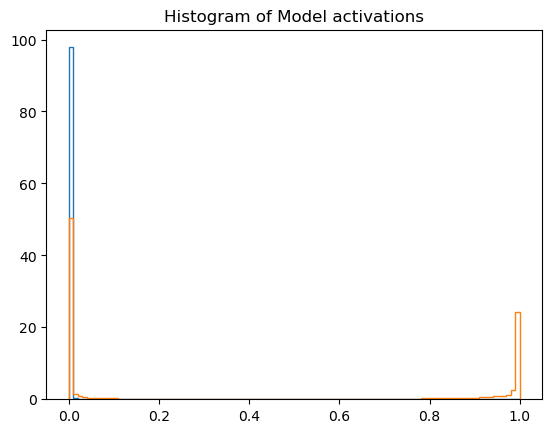

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(p[0], cmap='gray', vmin=0, vmax=1)
ax[0].axis('off')
ax[0].set_title("Model")
ax[1].imshow(p_tt[0], cmap='gray', vmin=0, vmax=1)
ax[1].axis('off')
ax[1].set_title("Model Two thresholds")
ax[2].imshow((gt_test[0]), cmap='gray', vmin=0, vmax=1)
ax[2].axis('off')
ax[2].set_title("True injections")
ax[3].imshow((gt_test[0] | (stack_fp[0] > 0.5)), cmap='gray', vmin=0, vmax=1)
ax[3].axis('off')
ax[3].set_title("True injections with stack sources")
fig.tight_layout()
plt.show()
plt.hist(p[gt_test<0.5].flatten(), density=True, bins=100, histtype='step')
plt.hist(p[gt_test>0.5].flatten(), density=True, bins=100, histtype='step')
plt.title("Histogram of Model activations")
plt.show()